In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

In [6]:
dt = [xr.open_dataset(i) for i in ["/kaggle/input/wrfinput-remal-one/wrfinput_d01","/kaggle/input/wrfinput-remal-one/wrfinput_d02"]]

dt[0]

<xarray.Dataset> Size: 159MB
Dimensions:               (Time: 1, south_north: 189, west_east: 189,
                           bottom_top: 44, bottom_top_stag: 45,
                           soil_layers_stag: 4, dust_erosion_dimension: 3,
                           west_east_stag: 190, south_north_stag: 190,
                           DIM0010: 5, land_cat_stag: 21, soil_cat_stag: 16,
                           num_ext_model_couple_dom_stag: 1)
Coordinates:
    XLAT                  (Time, south_north, west_east) float32 143kB ...
    XLONG                 (Time, south_north, west_east) float32 143kB ...
    XLAT_U                (Time, south_north, west_east_stag) float32 144kB ...
    XLONG_U               (Time, south_north, west_east_stag) float32 144kB ...
    XLAT_V                (Time, south_north_stag, west_east) float32 144kB ...
    XLONG_V               (Time, south_north_stag, west_east) float32 144kB ...
Dimensions without coordinates: Time, south_north, west_east, bottom_top,
                                bottom_top_stag, soil_layers_stag,
                                dust_erosion_dimension, west_east_stag,
                                south_north_stag, DIM0010, land_cat_stag,
                                soil_cat_stag, num_ext_model_couple_dom_stag
Data variables: (12/186)
    Times                 (Time) |S19 19B ...
    LU_INDEX              (Time, south_north, west_east) float32 143kB ...
    ZNU                   (Time, bottom_top) float32 176B ...
    ZNW                   (Time, bottom_top_stag) float32 180B ...
    ZS                    (Time, soil_layers_stag) float32 16B ...
    DZS                   (Time, soil_layers_stag) float32 16B ...
    ...                    ...
    C4F                   (Time, bottom_top_stag) float32 180B ...
    PCB                   (Time, south_north, west_east) float32 143kB ...
    PC                    (Time, south_north, west_east) float32 143kB ...
    LANDMASK              (Time, south_north, west_east) float32 143kB ...
    LAKEMASK              (Time, south_north, west_east) float32 143kB ...
    SST                   (Time, south_north, west_east) float32 143kB ...
Attributes: (12/90)
    TITLE:                            OUTPUT FROM REAL_EM V4.4 PREPROCESSOR
    START_DATE:                      2024-05-24_00:00:00
    SIMULATION_START_DATE:           2024-05-24_00:00:00
    WEST-EAST_GRID_DIMENSION:        190
    SOUTH-NORTH_GRID_DIMENSION:      190
    BOTTOM-TOP_GRID_DIMENSION:       45
    ...                              ...
    ISLAKE:                          21
    ISICE:                           15
    ISURBAN:                         13
    ISOILWATER:                      14
    HYBRID_OPT:                      2
    ETAC:                            0.2

In [10]:
np.array(list(dt[1].variables))

array(['Times', 'XLAT', 'XLONG', 'LU_INDEX', 'ZNU', 'ZNW', 'ZS', 'DZS',
       'VAR_SSO', 'EROD', 'BATHYMETRY_FLAG', 'U', 'V', 'W', 'PH', 'PHB',
       'T', 'THM', 'T_INIT', 'MU', 'MUB', 'P', 'AL', 'ALB', 'PB', 'FNM',
       'FNP', 'RDNW', 'RDN', 'DNW', 'DN', 'T_BASE', 'CFN', 'CFN1',
       'STEP_NUMBER', 'THIS_IS_AN_IDEAL_RUN', 'P_HYD', 'Q2', 'T2', 'TH2',
       'PSFC', 'U10', 'V10', 'RDX', 'RDY', 'DTS', 'DTSEPS', 'RESM',
       'ZETATOP', 'CF1', 'CF2', 'CF3', 'QVAPOR', 'QCLOUD', 'QRAIN',
       'QICE', 'QSNOW', 'QGRAUP', 'QNICE', 'QNRAIN', 'FCX', 'GCX',
       'TOPOSLPX', 'TOPOSLPY', 'SHDMAX', 'SHDMIN', 'SNOALB', 'LANDUSEF',
       'SOILCTOP', 'SOILCBOT', 'TSLB', 'SMOIS', 'SH2O', 'SMCREL',
       'SEAICE', 'IVGTYP', 'ISLTYP', 'VEGFRA', 'SNOW', 'SNOWH', 'CANWAT',
       'FNDSNOWH', 'FNDSOILW', 'FNDALBSI', 'FNDSNOWSI', 'FNDICEDEPTH',
       'LAKE_DEPTH', 'WATER_DEPTH', 'UOCE', 'VOCE', 'FRC_URB2D', 'LAI',
       'VAR', 'CON', 'OA1', 'OA2', 'OA3', 'OA4', 'OL1', 'OL2', 'OL3',
       'OL4'

In [102]:
lai1 = dt[0].LAI.values
lai2 = dt[1].LAI.values

luindex1= dt[0].LU_INDEX.values
luindex2= dt[1].LU_INDEX.values

lai1.shape, luindex1.shape, lai2.shape

((1, 189, 189), (1, 189, 189), (1, 188, 188))

array([[21.443825, 21.443825, 21.443825, 21.443825, 21.443825, 21.443825],
       [21.677658, 21.677658, 21.677658, 21.677658, 21.677658, 21.677658],
       [21.91111 , 21.91111 , 21.91111 , 21.91111 , 21.91111 , 21.91111 ],
       [22.14418 , 22.14418 , 22.14418 , 22.14418 , 22.14418 , 22.14418 ],
       [22.376862, 22.376862, 22.376862, 22.376862, 22.376862, 22.376862],
       [22.609161, 22.609161, 22.609161, 22.609161, 22.609161, 22.609161]],
      dtype=float32)

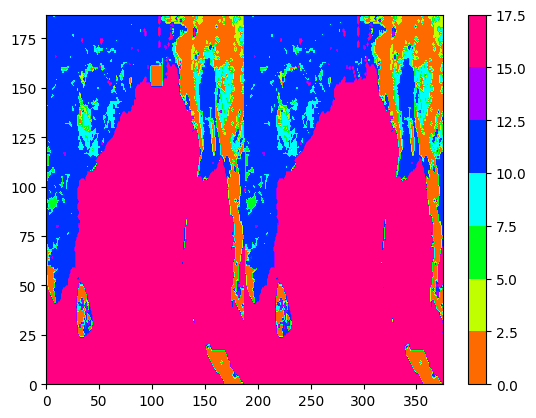

In [103]:
[21.56, 88.71,22.53,89.9]  # leftlat, leftlon, rightlat, rightlon

dt[0].XLAT.values[0,:,0]   # dt[0]: 21.443825, 22.609161; dt[1]: 21.50232,22.551117

dt[1].XLAT.values[0,:,0]   #dt[0]: 88.65142, 89.90853; dt[1]: 88.71428, 89.97138

lat1_, lon1_ = [list(dt[0].XLAT.values[0,:,0]).index(i) for i in np.array([21.443825, 22.609161], dtype = np.float32)], \
[list(dt[0].XLONG.values[0,0,:]).index(i) for i in np.array([88.65142, 89.90853],dtype = np.float32)]

lat2_, lon2_ = [list(dt[1].XLAT.values[0,:,0]).index(i) for i in np.array([21.50232,22.551117], dtype = np.float32)], \
[list(dt[1].XLONG.values[0,0,:]).index(i) for i in np.array([88.71428, 89.97138],dtype = np.float32)]


lat1, lon1 = dt[0].XLAT.values[0,lat1_[0]:lat1_[1]+1,0],dt[0].XLONG.values[0,0,lon1_[0]:lon1_[1]+1]

lat2, lon2 = dt[1].XLAT.values[0,lat2_[0]:lat2_[1]+1,0],dt[1].XLONG.values[0,0,lon2_[0]:lon2_[1]+1]

#lai_ = np.zeros(lai.shape[:])

lai1_ = lai1.copy()


for i in  range(len(lai1[0,:,0])):
    for j in range(len(lai1[0,0,:])):
        if lat1_[0]<=i<=lat1_[1]+1 and lon1_[0]<=j<=lon1_[1]+1:
            lai1_[0,i,j] = 0
            
        else:
            
            lai1_[0,i,j] = lai1[0,i,j]

luindex1_ = luindex1.copy()


for i in  range(len(lai1[0,:,0])):
    for j in range(len(lai1[0,0,:])):
        if lat1_[0]<=i<=lat1_[1]+1 and lon1_[0]<=j<=lon1_[1]+1:
            luindex1_[0,i,j] = 0
            
        else:
            
            luindex1_[0,i,j] = luindex1[0,i,j]

lai2_ = lai2.copy()


for i in  range(len(lai2[0,:,0])):
    for j in range(len(lai2[0,0,:])):
        if lat2_[0]<=i<=lat2_[1]+1 and lon2_[0]<=j<=lon2_[1]+1:
            lai2_[0,i,j] = 0
            
        else:
            
            lai2_[0,i,j] = lai2[0,i,j]

luindex2_ = luindex2.copy()


for i in  range(len(lai2[0,:,0])):
    for j in range(len(lai2[0,0,:])):
        if lat2_[0]<=i<=lat2_[1]+1 and lon2_[0]<=j<=lon2_[1]+1:
            luindex2_[0,i,j] = 0
            
        else:
            
            luindex2_[0,i,j] = luindex2[0,i,j]


m = plt.contourf(np.hstack([luindex2_[0,:,:],luindex2[0,:,:]]), cmap = "hsv")

plt.colorbar(m)


lat[0,lat1_[0]:lat1_[1]+1,lon1_[0]:lon1_[1]+1]


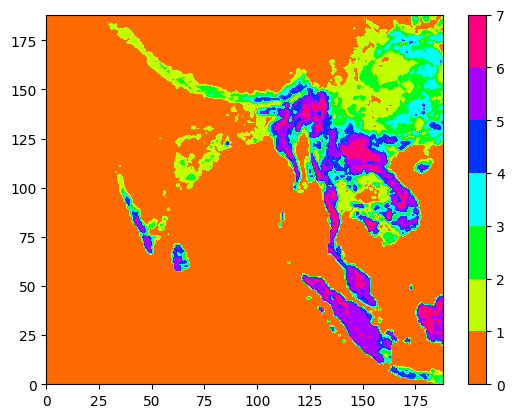

In [28]:
m = plt.contourf(lai[0,:,:], cmap = "hsv")
plt.colorbar(m)

In [1]:
"""LAI = Leaf Area Index, LU_INDEX = Land cover type, SMOIS = Soil Moisture, 
SH2O = Soil water content, SMCREL = relative soil moisture, ALBBCK = backgroudn albedo,
"""

'LAI = Leaf Area Index, LU_INDEX = Land cover type, SMOIS = Soil Moisture, \nSH2O = Soil water content, SMCREL = relative soil moisture, ALBBCK = backgroudn albedo,\n'

In [108]:
import xarray as xr
import numpy as np

ds = xr.open_dataset('/kaggle/input/wrfinput-remal-one/wrfinput_d01')

ds['LAI'].values = lai1_

ds['LU_INDEX'].values = luindex1_

ds.to_netcdf('/kaggle/working/wrfinput_d01')

ds.close()

ds = xr.open_dataset('/kaggle/input/wrfinput-remal-one/wrfinput_d02')
                     

ds['LAI'].values = lai2_

ds['LU_INDEX'].values = luindex2_

ds.to_netcdf('/kaggle/working/wrfinput_d02')

ds.close()

In [107]:
xr.open_dataset('/kaggle/working/wrfinput_d02')

<xarray.Dataset> Size: 158MB
Dimensions:               (Time: 1, south_north: 188, west_east: 188,
                           bottom_top: 44, bottom_top_stag: 45,
                           soil_layers_stag: 4, dust_erosion_dimension: 3,
                           west_east_stag: 189, south_north_stag: 189,
                           DIM0010: 5, land_cat_stag: 21, soil_cat_stag: 16,
                           num_ext_model_couple_dom_stag: 1)
Coordinates:
    XLAT                  (Time, south_north, west_east) float32 141kB ...
    XLONG                 (Time, south_north, west_east) float32 141kB ...
    XLAT_U                (Time, south_north, west_east_stag) float32 142kB ...
    XLONG_U               (Time, south_north, west_east_stag) float32 142kB ...
    XLAT_V                (Time, south_north_stag, west_east) float32 142kB ...
    XLONG_V               (Time, south_north_stag, west_east) float32 142kB ...
Dimensions without coordinates: Time, south_north, west_east, bottom_top,
                                bottom_top_stag, soil_layers_stag,
                                dust_erosion_dimension, west_east_stag,
                                south_north_stag, DIM0010, land_cat_stag,
                                soil_cat_stag, num_ext_model_couple_dom_stag
Data variables: (12/186)
    Times                 (Time) |S19 19B ...
    LU_INDEX              (Time, south_north, west_east) float32 141kB ...
    ZNU                   (Time, bottom_top) float32 176B ...
    ZNW                   (Time, bottom_top_stag) float32 180B ...
    ZS                    (Time, soil_layers_stag) float32 16B ...
    DZS                   (Time, soil_layers_stag) float32 16B ...
    ...                    ...
    C4F                   (Time, bottom_top_stag) float32 180B ...
    PCB                   (Time, south_north, west_east) float32 141kB ...
    PC                    (Time, south_north, west_east) float32 141kB ...
    LANDMASK              (Time, south_north, west_east) float32 141kB ...
    LAKEMASK              (Time, south_north, west_east) float32 141kB ...
    SST                   (Time, south_north, west_east) float32 141kB ...
Attributes: (12/90)
    TITLE:                            OUTPUT FROM REAL_EM V4.4 PREPROCESSOR
    START_DATE:                      2024-05-24_00:00:00
    SIMULATION_START_DATE:           2024-05-24_00:00:00
    WEST-EAST_GRID_DIMENSION:        189
    SOUTH-NORTH_GRID_DIMENSION:      189
    BOTTOM-TOP_GRID_DIMENSION:       45
    ...                              ...
    ISLAKE:                          21
    ISICE:                           15
    ISURBAN:                         13
    ISOILWATER:                      14
    HYBRID_OPT:                      2
    ETAC:                            0.2